<a href="https://colab.research.google.com/github/SEC-API-io/sec-api-cookbook/blob/main/notebooks/subsidiary-api/subsidiary-api-example.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Company Subsidary API with Python

This guide demonstrates how you can leverage the Company Subsidiary API to find subsidiaries and their jurisdictions for a company.

Overview of the tutorial:

- How to fetch all of Tesla's subsidiaries since its IPO in 2010.
- Techniques to visualize the number of Tesla's subsidiaries across different geographical regions over time.
- Mapping Tesla's subsidiaries on a world map, using circle bubbles sized proportionally to the number of subsidiaries in each location.


The Subsidiary API at a glance:

- Retrieve all current and historical subsidiaries of a company using its ticker, CIK, or get information on subsidiaries of multiple companies.
- Obtain a list of subsidiaries for a company since a specific date.
- Extract subsidiary data from a specific Exhibit 21 file, for example attached to 10-K or 10-Q reports.


## The Importance of Subsidiary Data

![subsidiary-locations-of-tesla](https://i.imgur.com/QLExJN1.png)


- **Revenue Indicators & Growth Trends:** A growing number of subsidiaries often signals future revenue growth. Setting up subsidiaries in new countries can indicate expansion into new markets.
- **Diversified Revenue Streams:** Geographically diverse subsidiaries can mean a company has multiple sources of revenue. This can protect the company from downturns in one specific market or region.
- **Corporate Structure & Risk:** Grasping the subsidiary network helps in understanding a company's structure, revealing potential risks in specific geographical regions and the company's exposure to them.
- **New Market Dynamics:** Are there trends unique to specific sectors or industries? For instance, do companies in a certain sector tend to establish subsidiaries in specific countries?
- **Cost Management**: Companies might establish subsidiaries in regions where operational costs, including labor and raw materials, are lower. This can provide insights into a company's cost management strategy.
- **Identifying Market Leaders**: The presence of multiple subsidiaries in a particular region can indicate which companies are market leaders there.
- **M&A Insights:** Recognizing patterns in subsidiary establishment can hint at potential mergers and acquisitions targets. Also, a sudden increase in subsidiaries in a particular region can hint at a company's M&A strategy.



## Fetching & Visualizing Subsidiary Location Trends over Time

Begin by installing the `sec-api` Python package. Once installed, initialize the `SubsidiaryApi` class using your API key. To retrieve the list of Tesla's subsidiaries since its 2010 IPO, we'll utilize the `subsidiary_api.get_data(query)` method.

In [ ]:
!pip install -q sec-api

In [ ]:
API_KEY = 'YOUR_API_KEY'

In [ ]:
from sec_api import SubsidiaryApi

subsidiary_api = SubsidiaryApi(API_KEY)

To extract the desired data, we'll be crafting a query and feeding it to the `subsidiary_api.get_data()` method. Here's how it's done:

In [ ]:
tsla_query = {
  "query": "ticker:TSLA",
  "from": "0",
  "size": "50",
  "sort": [ { "filedAt": { "order": "desc"  } } ]
}

tsla_subsidiaries = subsidiary_api.get_data(tsla_query)

### **Pagination**:
The `from` and `size` parameters help in managing pagination. Specifically:

- `from`: Denotes the starting point. For instance, setting "from" to "50" would start fetching from the 51st record.
- `size`: Specifies the number of records to fetch per query, maxing out at 50.

If you want to retrieve more data beyond your initial fetch of 50 results, increase the "from" parameter by increments of 50. Note, the combined value of "from" and "size" can't exceed 10,000.

### **Crafting Queries with Lucene Syntax**:

The `query` parameter uses the Lucene query syntax. This offers a versatile way to specify your search criteria. Examples include:

- `ticker:TSLA AND filedAt:[2020-01-01 TO 2022-12-31]`: This fetches subsidiaries of Tesla disclosed in filings between 2020 and 2022.
- `ticker:(MSFT, AAPL, NVDA)`: This targets subsidiaries of Microsoft, Apple, and Nvidia.
- `accessionNo:"0001564590-21-028714"`: This fetches subsidiaries from a specific Exhibit 21 file attached to the filing with the given accession number.

### **Understanding the Response**:

The data you receive is in JSON format, nested inside the `data` field of the response. Within this field, you'll find an array of subsidiary objects. Each object contains:

- `id`: A unique identifier.
- `accessionNo`: The accession number from the filing the data was extracted from.
- `filedAt`: The filing date.
- `cik`: The company's CIK.
- `ticker`: The company's ticker symbol.
- `companyName`: The company's name.
- `subsidiaries`: An array of subsidiary objects. Each of these has:
    - `name`: The subsidiary's name.
    - `jurisdiction`: The subsidiary's jurisdiction. This could be a US state (like Delaware) or a country (like China). However, note that not all subsidiaries will have a jurisdiction specified. Also, the jurisdictions are not standardized. For example, "UK" and "United Kingdom" are used by different companies.


In [ ]:
print("Most recent TSLA subsidiary data:")
tsla_subsidiaries['data'][0]

Most recent TSLA subsidiary data:


{'id': '6838a63b29128e116bde65c885282667',
 'accessionNo': '0000950170-23-001409',
 'filedAt': '2023-01-30T21:29:15-05:00',
 'cik': '1318605',
 'ticker': 'TSLA',
 'companyName': 'Tesla, Inc.',
 'subsidiaries': [{'name': 'Alabama Service LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Allegheny Solar 1, LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Allegheny Solar Manager 1, LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Alset Transport GmbH', 'jurisdiction': 'Germany'},
  {'name': 'Alset Warehouse GmbH', 'jurisdiction': 'Germany'},
  {'name': 'Ancon Holdings II, LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Ancon Holdings III, LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Ancon Holdings, LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Ancon Solar Corporation', 'jurisdiction': 'Delaware'},
  {'name': 'Ancon Solar I, LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Ancon Solar II Lessee Manager, LLC', 'jurisdiction': 'Delaware'},
  {'name': 'Ancon Solar II Lessee, LLC', 'jurisdiction': 'D

<!-- Convert JSON response into a Pandas dataframe for easier data manipulation. We drop the `id` and `companyName` columns as they are not needed for our analysis. We also explode the `subsidiaries` column into multiple rows, one for each subsidiary. Two new columns are created: `name` and `jurisdiction`, by extracting the `name` and `jurisdiction` fields from the `subsidiaries` column. Subsequently, we drop the `subsidiaries` column. -->

Next, we'll transform the JSON response into a Pandas dataframe. During this process, we'll make a few optimizations:

1. **Dropping Unnecessary Columns:** We'll remove the `id` and `companyName` columns, as they won't be utilized in our subsequent analysis.
2. **Expanding the `subsidiaries` Column:** This column, which contains arrays of subsidiary data, will be 'exploded' into individual rows, ensuring each subsidiary occupies its own row.
3. **Extracting Subsidiary Details:** From the exploded `subsidiaries` column, we'll create two new columns: `name` and `jurisdiction`. These columns will hold the respective `name` and `jurisdiction` data for each subsidiary.
4. **Cleaning Up:** After the above transformations, we'll discard the original `subsidiaries` column to maintain a tidy dataframe.



In [ ]:
import pandas as pd

In [ ]:
tsla_subsidiaries_df = pd.DataFrame(tsla_subsidiaries['data'])
# drop columns: id, companyName
tsla_subsidiaries_df = tsla_subsidiaries_df.drop(['id', 'companyName'], axis=1)
# explode subsidiaries column
tsla_subsidiaries_df = tsla_subsidiaries_df.explode('subsidiaries')
# explode subsidiaries column to new "name" and "jurisdiction" columns
tsla_subsidiaries_df[['name', 'jurisdiction']] = tsla_subsidiaries_df['subsidiaries'].apply(pd.Series)
# drop subsidiaries column
tsla_subsidiaries_df = tsla_subsidiaries_df.drop(['subsidiaries'], axis=1)

In [ ]:
print("All TSLA subsidiaries since its IPO in 2010:")
tsla_subsidiaries_df

All TSLA subsidiaries since its IPO in 2010:


,accessionNo,filedAt,cik,ticker,name,jurisdiction
0,0000950170-23-001409,2023-01-30T21:29:15-05:00,1318605,TSLA,Alabama Service LLC,Delaware
0,0000950170-23-001409,2023-01-30T21:29:15-05:00,1318605,TSLA,"Allegheny Solar 1, LLC",Delaware
0,0000950170-23-001409,2023-01-30T21:29:15-05:00,1318605,TSLA,"Allegheny Solar Manager 1, LLC",Delaware
0,0000950170-23-001409,2023-01-30T21:29:15-05:00,1318605,TSLA,Alset Transport GmbH,Germany
0,0000950170-23-001409,2023-01-30T21:29:15-05:00,1318605,TSLA,Alset Warehouse GmbH,Germany
...,...,...,...,...,...,...
9,0001193125-10-129878,2010-05-27T06:07:36-04:00,1318605,TSLA,"Tesla Motors Australia, Pty Ltd.",Australia
9,0001193125-10-129878,2010-05-27T06:07:36-04:00,1318605,TSLA,Tesla Motors Japan K.K.,Japan
9,0001193125-10-129878,2010-05-27T06:07:36-04:00,1318605,TSLA,Tesla Motors HK Limited,Hong Kong
9,0001193125-10-129878,2010-05-27T06:07:36-04:00,1318605,TSLA,Tesla Motors Italy S.r.l.,Italy


In [ ]:
print("Unique reporting dates:", tsla_subsidiaries_df['filedAt'].nunique(), "\n", tsla_subsidiaries_df['filedAt'].unique())
print("Unique juristdictions:", tsla_subsidiaries_df['jurisdiction'].nunique(), "\n", tsla_subsidiaries_df['jurisdiction'].sort_values().unique())

Unique reporting dates: 10 
 ['2023-01-30T21:29:15-05:00' '2022-02-04T20:11:27-05:00'
 '2021-02-08T07:27:23-05:00' '2020-02-13T07:12:18-05:00'
 '2019-02-19T06:10:16-05:00' '2018-02-23T06:07:43-05:00'
 '2017-03-01T16:54:21-05:00' '2016-02-24T16:17:56-05:00'
 '2011-03-03T14:47:36-05:00' '2010-05-27T06:07:36-04:00']
Unique juristdictions: 67 
 ['' 'Arizona' 'Australia' 'Austria' 'Belgium' 'California' 'Canada'
 'Cayman' 'Cayman Islands' 'China' 'Croatia' 'Czech Republic' 'Delaware'
 'Delware' 'Denmark' 'Finland' 'Florida' 'France' 'Germany' 'Greece'
 'Guam' 'Hong Kong' 'Hungary' 'Iceland' 'Illinois' 'India' 'Ireland'
 'Israel' 'Italy' 'Japan' 'Jordan' 'Luxembourg' 'Macau' 'Malaysia' 'Malta'
 'Massachusetts' 'Mexico' 'Michigan' 'Minnesota' 'Monaco' 'Netherlands'
 'Nevada' 'New York' 'New Zealand' 'Norway' 'Ontario' 'Pennsylvania'
 'Poland' 'Portugal' 'Puerto Rico' 'Republic of Korea' 'Romania'
 'Singapore' 'Slovenia' 'South Korea' 'Spain' 'Sweden' 'Switzerland'
 'Taiwan' 'Tennessee' 'Texas

Our dataset is spanning 10 unique reporting periods. These periods include the years from 2016 to 2023, as well as 2010 and 2011. If you're wondering about the gap between 2012 and 2015, Tesla did not report any subsidiaries in their EDGAR filings during this window, which explains their absence in our dataset.

Diving into jurisdictions, our data captures subsidiaries in 62 distinct regions. These include jurisdictions such as Delaware, California, China, and Germany. Note, that "Delaware" and "Delware", "UK" and "United Kingdom", "Republic of Korea" and "South Korea" as well as "Cayman" and "Cayman Islands" are considered the same jurisdictions, and that we have to standardize them before we can analyze the data.

In [ ]:
replace_jurisdictions = {
    'Delware': 'Delaware',
    'UK': 'United Kingdom',
    'Cayman': 'Cayman Islands',
    'South Korea': 'Republic of Korea'
}
tsla_subsidiaries_df['jurisdiction'] = tsla_subsidiaries_df['jurisdiction'].replace(replace_jurisdictions)

For a closer look at recent trends, we'll spotlight the top 10 jurisdictions with the highest concentration of Tesla subsidiaries in 2022.

In [ ]:
print("Top 10 Regions with the most Tesla Subsidiaries in 2022:")
top_locations_2022 = pd.DataFrame(tsla_subsidiaries_df[tsla_subsidiaries_df['filedAt'].str.contains('2022-')]['jurisdiction'].value_counts())
top_locations_2022.head(10)

Top 10 Regions with the most Tesla Subsidiaries in 2022:


,count
jurisdiction,
Delaware,237
China,45
California,11
Germany,7
Netherlands,7
Canada,6
Australia,4
Mexico,4
Cayman Islands,3


In [ ]:
# count number of subsidiaries per year
tsla_subsidiaries_df['year'] = tsla_subsidiaries_df['filedAt'].str[:4]
# group by year, name, jurisdiction and count number of subsidiaries
tsla_grouped = tsla_subsidiaries_df.groupby(['year', 'name', 'jurisdiction']).size().reset_index(name='count')
# group by year and jurisdiction and count number of subsidiaries
tsla_subs_juri_year = tsla_grouped.groupby(['year', 'jurisdiction']).size().reset_index(name='count')

In [ ]:
# create pivot table
tsla_subs_juri_year_pivot = tsla_subs_juri_year.pivot(index='year', columns='jurisdiction', values='count')
tsla_subs_juri_year_pivot

jurisdiction,,Arizona,Australia,Austria,Belgium,California,Canada,Cayman Islands,China,Croatia,...,Sweden,Switzerland,Taiwan,Tennessee,Texas,Thailand,Turkey,United Kingdom,United States,Utah
year,,,,,,,,,,,,,,,,,,,,,
2010,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN
2011,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,...,NaN,1.0,1.0,NaN,NaN,NaN,NaN,1.0,2.0,NaN
2016,NaN,NaN,1.0,1.0,1.0,NaN,1.0,NaN,12.0,NaN,...,1.0,1.0,NaN,1.0,1.0,NaN,NaN,2.0,NaN,1.0
2017,NaN,1.0,2.0,1.0,1.0,14.0,5.0,3.0,15.0,NaN,...,1.0,1.0,1.0,1.0,1.0,NaN,NaN,3.0,NaN,1.0
2018,NaN,NaN,1.0,1.0,1.0,14.0,3.0,NaN,18.0,NaN,...,1.0,1.0,1.0,1.0,1.0,NaN,1.0,2.0,NaN,1.0
2019,NaN,NaN,1.0,1.0,1.0,14.0,3.0,NaN,27.0,NaN,...,1.0,1.0,1.0,1.0,1.0,NaN,1.0,2.0,NaN,1.0
2020,NaN,NaN,2.0,1.0,1.0,15.0,5.0,NaN,35.0,NaN,...,1.0,1.0,1.0,1.0,1.0,NaN,1.0,2.0,NaN,1.0
2021,NaN,NaN,4.0,1.0,1.0,12.0,5.0,3.0,45.0,1.0,...,1.0,1.0,1.0,1.0,2.0,NaN,1.0,2.0,NaN,1.0
2022,1.0,NaN,4.0,1.0,1.0,11.0,6.0,3.0,45.0,1.0,...,1.0,1.0,1.0,1.0,3.0,NaN,1.0,2.0,NaN,1.0


In [ ]:
top_10_locations = top_locations_2022.head(10).index.tolist()

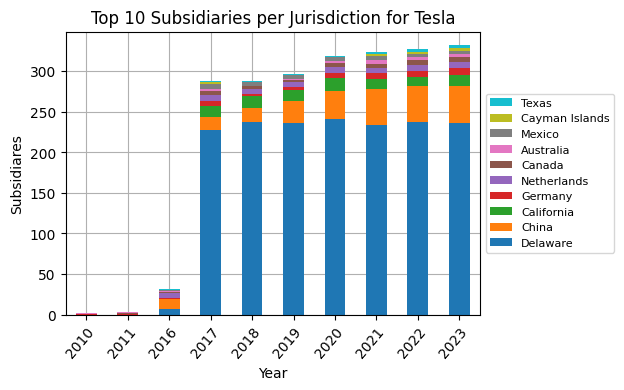

In [ ]:
import matplotlib.pyplot as plt

# plot tsla_subs_juri_year_pivot for top 10 locations
tsla_subs_juri_year_pivot[top_10_locations].plot(kind='bar', stacked=True, figsize=(5, 4))
plt.title("Top 10 Subsidiaries per Jurisdiction for Tesla")
plt.ylabel("Subsidiares"), plt.xlabel("Year"), plt.tight_layout()
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(), ax.set_axisbelow(True)
plt.setp(ax.get_xticklabels(), rotation=50, ha="right", rotation_mode="anchor")
plt.show()

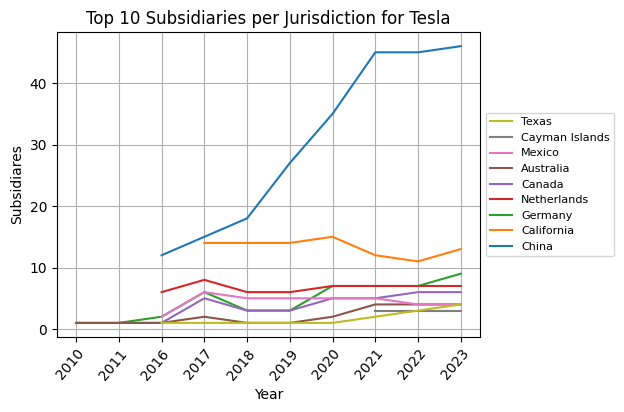

In [ ]:
tsla_subs_juri_year_pivot[top_10_locations[1:]].plot(figsize=(5, 4))
plt.title("Top 10 Subsidiaries per Jurisdiction for Tesla")
plt.ylabel("Subsidiares"), plt.xlabel("Year"), plt.tight_layout()
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
ax.legend(reversed(handles), reversed(labels), loc='center left', bbox_to_anchor=(1, 0.5), fontsize=8)
ax.grid(), ax.set_axisbelow(True)
plt.xticks(range(len(tsla_subs_juri_year_pivot.index)), tsla_subs_juri_year_pivot.index)
plt.setp(ax.get_xticklabels(), rotation=50, ha="right", rotation_mode="anchor")
plt.show()

## Visualizing Subsidiary Locations on a World Map

In this section, we chart the global locations of Telsa's subsidiaries reported in 2022 on a world map.

Our dataset contains many location names, with the majority representing countries and a handful denoting US states. However, it's vital to understand that these jurisdictions aren't universally standardized. For instance, while one filer might denote a location as "United Kingdom", another might simply use "UK". Although we streamlined Tesla's jurisdictions in the previous section, this method isn't always feasible on a larger scale.

<!-- We have the location names of all subsidiaries in the dataset, most of them represent countries, some of them US states. Note, the jurisdications are not standardized. For example, a filer might report "United Kingdom" as the jurisdiction, while another filer might report "UK". While we manually standardized Tesla's subsidiaries' jurisdictions in the previous section, this is not a scalable solution.  -->

<!-- The challenge here lies within mapping a location, such as China, to its latidual and longitudal coordinates, such as (35, 105). In order to achieve this, we use the GeoNames database that hosts a list of all countries, states, cities and other objects and their corresponding latitude and longitudal coordinates.  -->

One of the primary challenges we face is translating these location names into precise geographical coordinates. For instance, how do we pinpoint a country like China to its latitude and longitude, say (35, 105)? Our solution is the [GeoNames database](http://download.geonames.org/export/dump/), an extensive resource that catalogues a vast array of geographical entities, from countries and states to cities, and pairs them with their respective coordinates.

<!-- For this tutorial, we manually download and process the [GeoNames database](http://download.geonames.org/export/dump/) allowing you to understand the mapping process. However, if you want to make your life easier later on, you can use the [`geonamescache` Python package](https://pypi.org/project/geonamescache/) to access the database and retrieve the coordinates for each location in the dataset. Note, the `allCountries.zip` file is 1.5GB in size and contains over 12 million rows. -->

For the purpose of this tutorial, we'll walk you through the manual download and processing of the [GeoNames database](http://download.geonames.org/export/dump/). This hands-on approach ensures a thorough understanding of the mapping process. However, for those looking for a more streamlined solution, the [`geonamescache` Python package](https://pypi.org/project/geonamescache/) offers direct access to this database. Do bear in mind that the `allCountries.zip` file from GeoNames is quite large, weighing in at 1.5GB and encompassing over 12 million rows.

Once we've added the coordinates of all jurisdictions to our dataset, we'll visualize Tesla's global footprint on a world map using the `plotly` Python package.

The first step involves downloading the [`allCountries.zip` file from GeoNames database](http://download.geonames.org/export/dump/allCountries.zip) and unzipping it. The database is a tab-separated file with, among others, the following columns:
- `geonameid` - integer id of record
- `name` - name of geographical point
- `asciiname` - name of geographical point in plain ascii characters
- `latitude` - latitude in decimal degrees
- `longitude` - longitude in decimal degrees
- `feature class` - categorization of the geographic feature, see [codes](http://www.geonames.org/export/codes.html) for more info
- `feature code` - detailed description within the feature class, see [codes](http://www.geonames.org/export/codes.html) for more info
- `country code` - ISO-3166 2-letter country code
- `population` - population of geographical point

In [ ]:
# set to path to GeoNames database file
geonames_db_file = '/Users/jan/Downloads/allCountries.txt'

In [ ]:
# load first three lines GeoNames database file into pandas dataframe
import pandas as pd

df = pd.read_csv(geonames_db_file, sep='\t', nrows=3, header=None)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,2986043,Pic de Font Blanca,Pic de Font Blanca,"Pic de Font Blanca,Pic du Port",42.64991,1.53335,T,PK,AD,NaN,0,NaN,NaN,NaN,0,NaN,2860,Europe/Andorra,2014-11-05
1,2994701,Roc Mélé,Roc Mele,"Roc Mele,Roc Meler,Roc Mélé",42.58765,1.74028,T,MT,AD,"AD,FR",0,NaN,NaN,NaN,0,NaN,2803,Europe/Andorra,2020-06-10
2,3007683,Pic des Langounelles,Pic des Langounelles,Pic des Langounelles,42.61203,1.47364,T,PK,AD,"AD,FR",0,NaN,NaN,NaN,0,NaN,2685,Europe/Andorra,2014-11-05


Given the extensive size of GeoNames database, it's crucial to optimize our workflow. To achieve this:

1. **Selective Loading:** We'll load only a subset of all available columns into the Pandas dataframe named `all_locations`.
2. **Filtering by Feature Class:** We'll narrow down our geo dataset to include rows where the `feature_class` is either:
   - `P` (representing cities, villages, etc.) or
   - `A` (indicating larger geographical entities like countries, states, or regions).
3. **Creating Specific Dataframes for Efficient Retrieval:**
   - `countries_only`: This dataframe is tailored to quickly fetch country coordinates. It exclusively houses rows where the `feature_code` is `PCLI`.
   - `us_only`: Specifically for US data, this dataframe filters rows by the `country_code` set to `US`, enabling fast lookups of US state coordinates.
   
Without these optimizations, the process of assigning coordinates to our subsidiaries could be painstakingly slow, potentially taking between 10 to 20 minutes. And when iterating for testing, the duration would only increase.

In [ ]:
# load the geonames data (considering only the needed columns for simplicity)
all_locations = pd.read_csv(geonames_db_file,
                            sep='\t',
                            header=None,
                            names=['geonameid', 'name', 'asciiname', 'latitude', 'longitude', 'feature_class', 'feature_code', 'country_code', 'population'],
                            usecols=[0, 1, 2, 4, 5, 6, 7, 8, 14],
                            dtype=str)
# remove all rows with feature_class that are irrelevant for our use case, e.g. 'H' (e.g. lakes) 'L' (e.g. parks)
all_locations = all_locations[all_locations['feature_class'].isin(['A', 'P'])]
all_locations['population'] = all_locations['population'].astype(int)
all_locations['asciiname_lower'] = all_locations['asciiname'].str.lower()
all_locations['asciiname_lower'] = all_locations['asciiname_lower'].fillna('')
# countries_only
countries_only = all_locations[all_locations['feature_code'] == 'PCLI']
# US only
us_only = all_locations[(all_locations['country_code'] == 'US') &
                        (all_locations['feature_class'] == 'A') &
                        (all_locations['feature_code'] == 'ADM1')]

In [ ]:
all_locations[(all_locations['feature_class'] == 'A') & (all_locations['name'].str.contains('Germany'))]

,geonameid,name,asciiname,latitude,longitude,feature_class,feature_code,country_code,population,asciiname_lower
2736783,2921044,Federal Republic of Germany,Federal Republic of Germany,51.5,10.5,A,PCLI,DE,82927922,federal republic of germany
10264230,4558181,Township of Germany,Township of Germany,39.7369,-77.10788,A,ADM3,US,0,township of germany
10734394,5039087,City of New Germany,City of New Germany,44.88361,-93.97083,A,ADM3,US,0,city of new germany
10734802,5039499,Township of North Germany,Township of North Germany,46.58651,-94.96762,A,ADM3,US,0,township of north germany


To translate a given jurisdiction into its respective coordinates, we'll deploy a multi-step approach:

1. **Country Check:** We first determine if the jurisdiction represents a country. If it does, we extract the coordinates from the `countries_only` dataframe.
2. **US State Assumption:** If the jurisdiction isn't a country, we treat it as a potential US state (like Texas) and look up its coordinates in the `us_only` dataframe.
3. **General Lookup:** For jurisdictions that aren't captured as countries or US states (e.g., Puerto Rico), we turn to the `all_locations` dataframe. Within this frame, we sort potential matches by population and select the coordinates of the most populous match.

However, it's essential to note that this method isn't flawless. Our matching mechanism, which uses a simple `.contains` check on lowercased versions of the jurisdiction and the `asciiname` from the GeoNames database, can occasionally misfire. For example, the abbreviation `UK` might erroneously match with `Ukraine`. To bolster accuracy, consider more advanced matching techniques like the [Levenshtein distance](https://en.wikipedia.org/wiki/Levenshtein_distance). Alternatively, in a professional context, using APIs like [Google's Geocoding API](https://developers.google.com/maps/documentation/geocoding/overview) is the way to go. For the sake of this tutorial, we're prioritizing simplicity.


In [ ]:
def get_lat_lon(place_name):
    place_data = countries_only[countries_only['asciiname_lower'].str.contains(place_name.lower())]

    if not place_data.empty:
        latitude = place_data.iloc[0]['latitude']
        longitude = place_data.iloc[0]['longitude']
        return latitude, longitude

    # look for locations in the US only
    state_data = us_only[us_only['asciiname_lower'].str.contains(place_name.lower())]

    if not state_data.empty:
        latitude = state_data.iloc[0]['latitude']
        longitude = state_data.iloc[0]['longitude']
        return latitude, longitude

    print(place_name, "- no location found in countries and US states, looking in all locations now.")

    # look for matches in all_locations
    all_data = all_locations[all_locations['asciiname_lower'].str.contains(place_name.lower())]

    if not all_data.empty:
        all_data = all_data.sort_values(by='population', ascending=False)
        latitude = all_data.iloc[0]['latitude']
        longitude = all_data.iloc[0]['longitude']
        return latitude, longitude

    return None, None

In [ ]:
print(f"Delaware latitude & longitude: {get_lat_lon('Delaware')}")
print(f"Germany latitude & longitude: {get_lat_lon('Germany')}")
print(f"China latitude & longitude: {get_lat_lon('China')}")
print(f"Republic of Korea latitude & longitude: {get_lat_lon('Republic of Korea')}") # South Korea is not in the database
print(f"UK latitude & longitude: {get_lat_lon('UK')}") # false positive with Ukraine
print(f"United Kingdom latitude & longitude: {get_lat_lon('United Kingdom')}")

Delaware latitude & longitude: ('39.00039', '-75.49992')
Germany latitude & longitude: ('51.5', '10.5')
China latitude & longitude: ('35', '105')
Republic of Korea latitude & longitude: ('40', '127')
UK latitude & longitude: ('49', '32')
United Kingdom latitude & longitude: ('54.75844', '-2.69531')


In [ ]:
print(f"Cayman Islands latitude & longitude: {get_lat_lon('Cayman Islands')}")

Cayman Islands - no location found in countries and US states, looking in all locations now.
Cayman Islands latitude & longitude: ('19.5', '-80.66667')


In [ ]:
view_2022 = tsla_subsidiaries_df['filedAt'].str.contains('2022')
subs_2022 = tsla_subsidiaries_df[view_2022]
# count number of names grouped by jurisdiction
subs_2022_count = subs_2022.groupby('jurisdiction').count()['name'].sort_values(ascending=False)
# convert subs_2022_count to dataframe with columns jurisdiction and count
subs_2022_count = subs_2022_count.reset_index(name='count')

In [ ]:
subs_2022_count.head()

,jurisdiction,count
0,Delaware,237
1,China,45
2,California,11
3,Germany,7
4,Netherlands,7


The GeoNames database occasionally uses unique naming conventions for countries. For instance, instead of the commonly used "Italy," the database lists it as the "Italian Republic." To address this, we manually map such jurisdiction names from our dataset to their corresponding labels in GeoNames. The mappings are as follows:

In [ ]:
geoname_mappings = {
    'Czech Republic': 'Czechia',
    'Italy': 'Italian Republic',
    'Portugal': 'Portuguese Republic'
}

subs_2022_count['jurisdiction'] = subs_2022_count['jurisdiction'].replace(geoname_mappings)

In [ ]:
subs_2022_count['Lat-Long'] = subs_2022_count['jurisdiction'].apply(lambda x: get_lat_lon(x))
subs_2022_count['Latitude'] = subs_2022_count['Lat-Long'].apply(lambda x: x[0] if x else None)
subs_2022_count['Longitude'] = subs_2022_count['Lat-Long'].apply(lambda x: x[1] if x else None)

Hong Kong - no location found in countries and US states, looking in all locations now.
Cayman Islands - no location found in countries and US states, looking in all locations now.
Greece - no location found in countries and US states, looking in all locations now.
Macau - no location found in countries and US states, looking in all locations now.
Puerto Rico - no location found in countries and US states, looking in all locations now.


In [ ]:
subs_2022_count.head()

,jurisdiction,count,Lat-Long,Latitude,Longitude
0,Delaware,237,"(39.00039, -75.49992)",39.00039,-75.49992
1,China,45,"(35, 105)",35,105
2,California,11,"(37.25022, -119.75126)",37.25022,-119.75126
3,Germany,7,"(51.5, 10.5)",51.5,10.5
4,Netherlands,7,"(52.25, 5.75)",52.25,5.75


With latitude and longitude values now assigned to each jurisdiction, we'll use `plotly` to visualize the subsidiary locations. On our world map, subsidiaries and their counts will be depicted as circles, providing an excellent spatial representation of their geographical distribution.

In [ ]:
!pip install -q plotly

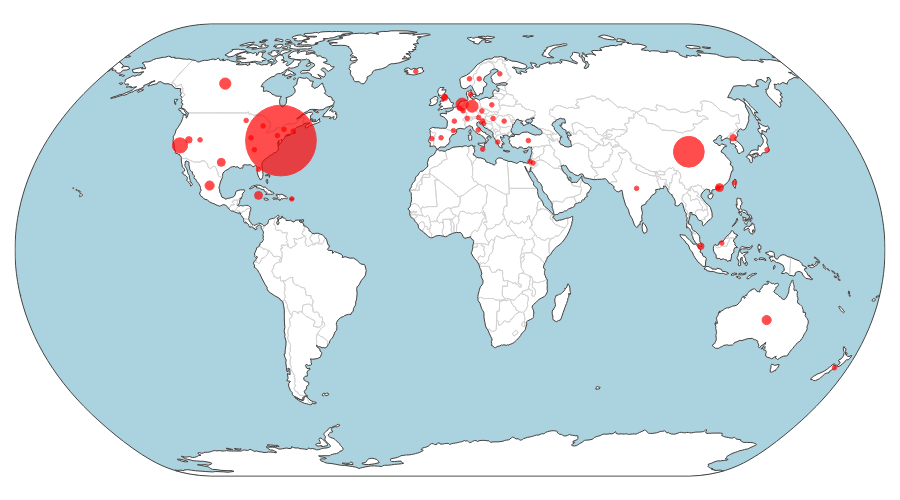

In [ ]:
import plotly.express as px

fig = px.scatter_geo(subs_2022_count, lat="Latitude", lon="Longitude", size="count",
                     size_max=50,
                     hover_name="jurisdiction",
                     hover_data=["count"],
                     color="count",
                     color_continuous_scale=px.colors.sequential.Plasma)
fig.update_traces(marker=dict(line=dict(width=1, color='red'), color='red'))
fig.update_geos(projection_type="natural earth",
                landcolor="white",
                showocean=True, oceancolor="#aad3df",
                showcountries=True, countrycolor="lightgrey")
fig.update_layout(width=900, height=500, margin={"r":15,"t":0,"l":15,"b":0})
# show map as PNG, not interactive
fig.show(renderer="png")